# Pre-processing
## Lucy Gagnon

In [1]:
#import packages
import numpy as np
import pandas as pd
import glob
import os
import re
import matplotlib.pyplot as plt
import rasterio
from collections import defaultdict
from scipy.spatial import cKDTree

%matplotlib inline
os.chdir('/home/jovyan')

In [2]:
# define functions

# parse date from filename
def parse_date(file):
    # find the 'doyYYYYJJJ...' pattern (e.g. doy2019364000000 -> capture '2019364')
    m = re.search(r'doy(\d{7})', os.path.basename(file))
    if m:
        return m.group(1)
    
#convert key to timestamp
def string_to_timestamp(yyyydoy):
    year = int(yyyydoy[:4])
    doy  = int(yyyydoy[4:7])
    return pd.to_datetime(f"{year}-{doy}", format="%Y-%j")


In [3]:
#load files
files = glob.glob("/shared_space/Galveston_Bay/*")
files

['/shared_space/Galveston_Bay/water_temp',
 '/shared_space/Galveston_Bay/MODIS_500',
 '/shared_space/Galveston_Bay/samples.csv',
 '/shared_space/Galveston_Bay/Observed_Temp_Data.csv',
 '/shared_space/Galveston_Bay/Observed_Raw',
 '/shared_space/Galveston_Bay/MODIS_test',
 '/shared_space/Galveston_Bay/MODIS_250',
 '/shared_space/Galveston_Bay/targets.csv',
 '/shared_space/Galveston_Bay/MODIS_files',
 '/shared_space/Galveston_Bay/feature_corr_new.png',
 '/shared_space/Galveston_Bay/Observed_Processed',
 '/shared_space/Galveston_Bay/feature_corr.png',
 '/shared_space/Galveston_Bay/ERA5']

In [44]:
#load observed data
file = '/shared_space/Galveston_Bay/Observed_Processed/Observed_DO_Data_w_predictions.csv' #'/shared_space/Galveston_Bay/All_Observed_Data.csv'
fp_og = pd.read_csv(file)
fp = fp_og[fp_og['type'] == 'Predicted']
fp = fp.drop(columns='type')
#print(fp.head())
lat_obs = fp['lat']
lon_obs = fp['lon']
#print(datetime)
#what are units of DO??
#convert targets to UTC for now
fp['DateTime'] = pd.to_datetime(fp['DateTime'])

# assign LT to ground obs
fp['datetime_local'] = fp['DateTime'].dt.tz_localize('America/Chicago', ambiguous='infer')  # attach tz
# convert ground obs to UTC (easier for merging with ERA, MODIS)
fp['datetime_utc'] = fp['datetime_local'].dt.tz_convert('UTC')
fp['datetime_utc'] = pd.to_datetime(fp['datetime_utc'])
fp['datetime_utc'] = fp['datetime_utc'].dt.tz_localize(None) #remove tz info
y = fp['DO'].values #extract targets
print(fp.head()) #check

      DateTime      lat      lon        DO            datetime_local  \
935 2018-01-23  29.5566 -94.9045  9.149207 2018-01-23 00:00:00-06:00   
936 2018-01-23  29.5566 -94.9045  9.086007 2018-01-23 00:00:00-06:00   
937 2018-01-23  29.5566 -94.9045  9.109207 2018-01-23 00:00:00-06:00   
938 2018-01-23  29.5566 -94.9045  9.156907 2018-01-23 00:00:00-06:00   
939 2018-01-23  29.5566 -94.9045  9.093707 2018-01-23 00:00:00-06:00   

           datetime_utc  
935 2018-01-23 06:00:00  
936 2018-01-23 06:00:00  
937 2018-01-23 06:00:00  
938 2018-01-23 06:00:00  
939 2018-01-23 06:00:00  


In [45]:
#load ERA data
import xarray as xr
file = '/shared_space/Galveston_Bay/ERA5/ERA5-2018-2020_rescaled.nc'
ds = xr.open_dataset(file)

#lat_era = ds['lat'].values
#lon_era = ds['lon'].values
#wind_speed = ds['wind_speed'].values
#sst = ds['sst'].values
ds

<xarray.Dataset>
Dimensions:     (latitude: 20, longitude: 20, valid_time: 26304)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2018-01-01 ... 2020-12-31T23:00:00
  * latitude    (latitude) float64 28.5 28.6 28.7 28.8 ... 30.1 30.2 30.3 30.4
  * longitude   (longitude) float64 -96.0 -95.9 -95.8 ... -94.3 -94.2 -94.1
Data variables:
    u10         (valid_time, latitude, longitude) float64 ...
    v10         (valid_time, latitude, longitude) float64 ...
    ssr         (valid_time, latitude, longitude) float64 ...
    t2m         (valid_time, latitude, longitude) float64 ...
    wind_speed  (valid_time, latitude, longitude) float64 ...

The ERA5 dataset includes lat, lon, time coordinates for the following variables: u10 and v10, which describe the eastward and northward component of wind, respectively; wind_speed; and sst, which gives sea surface temperature. The coordinates lat, lon are $0.25^o \times 0.25 ^o$ resolution and we have hourly data for 2019-2020. We will ask **Grace** if she already calculates wind_speed from the 10m bands; it seems so. Latitude is decreasing, longitude is increasing (-180,180). The lat, lon are in separate arrays.

In [46]:
#load and group the MODIS red, nir, and qc by date

from collections import defaultdict

# list files
# files_250m_2019 = glob.glob("/shared_space/Galveston_Bay/MODIS_files/*")
# files_250m_2019 = sorted(files)

files_500m_2020 = glob.glob('./shared_space/Galveston_Bay/MODIS_500/bands2020/*')
files_500m_2019 = glob.glob('./shared_space/Galveston_Bay/MODIS_500/*2019*')
files_500m_2018 = glob.glob('./shared_space/Galveston_Bay/MODIS_500/bands2018/*')

all_modis = files_500m_2020 + files_500m_2019 + files_500m_2018
all_files = sorted(all_modis)

# group files by datetime
groups = defaultdict(list)
for file in all_files:
    key = parse_date(file)
    #groups[key].append(file)
    if key is None:
        continue      # skip files without a valid date
    groups[key].append(file)
#check
print(len(groups))

1094


In [47]:
#ust to double check all the years are there
counts = {
    "2018": sum("2018" in f for f in all_files),
    "2019": sum("2019" in f for f in all_files),
    "2020": sum("2020" in f for f in all_files)
}

print(counts)


{'2018': 3007, '2019': 3003, '2020': 2938}


In [48]:
keys = list(groups.keys())   #extract filenames in groups            
times = np.array([string_to_timestamp(k) for k in keys])
index = pd.DatetimeIndex(times)

## explore MODIS datasets

In [49]:
#load sample MODIS
data_file = '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019364000000_aid0001.tif'

In [17]:
#read file 
with rasterio.open(data_file, 'r') as dataset:
    # print summary
    print(f"CRS: {dataset.crs}")
    print(f"Bounds: {dataset.bounds}")
    print(f"Width: {dataset.width}")
    print(f"Height: {dataset.height}")
    print(f"Number of bands: {dataset.count}")
    print(f"Band 1 data type: {dataset.dtypes[0]}")

    #read in band
    band1_data = dataset.read(1) 
    #check
    print(f"Shape of band 1 data: {band1_data.shape}")

CRS: EPSG:4326
Bounds: BoundingBox(left=-96.00208332473296, bottom=28.49999999744682, right=-93.99999999157899, top=30.00208333064559)
Width: 961
Height: 721
Number of bands: 1
Band 1 data type: int16
Shape of band 1 data: (721, 961)


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:34: RuntimeWarning: invalid value encountered in true_divide


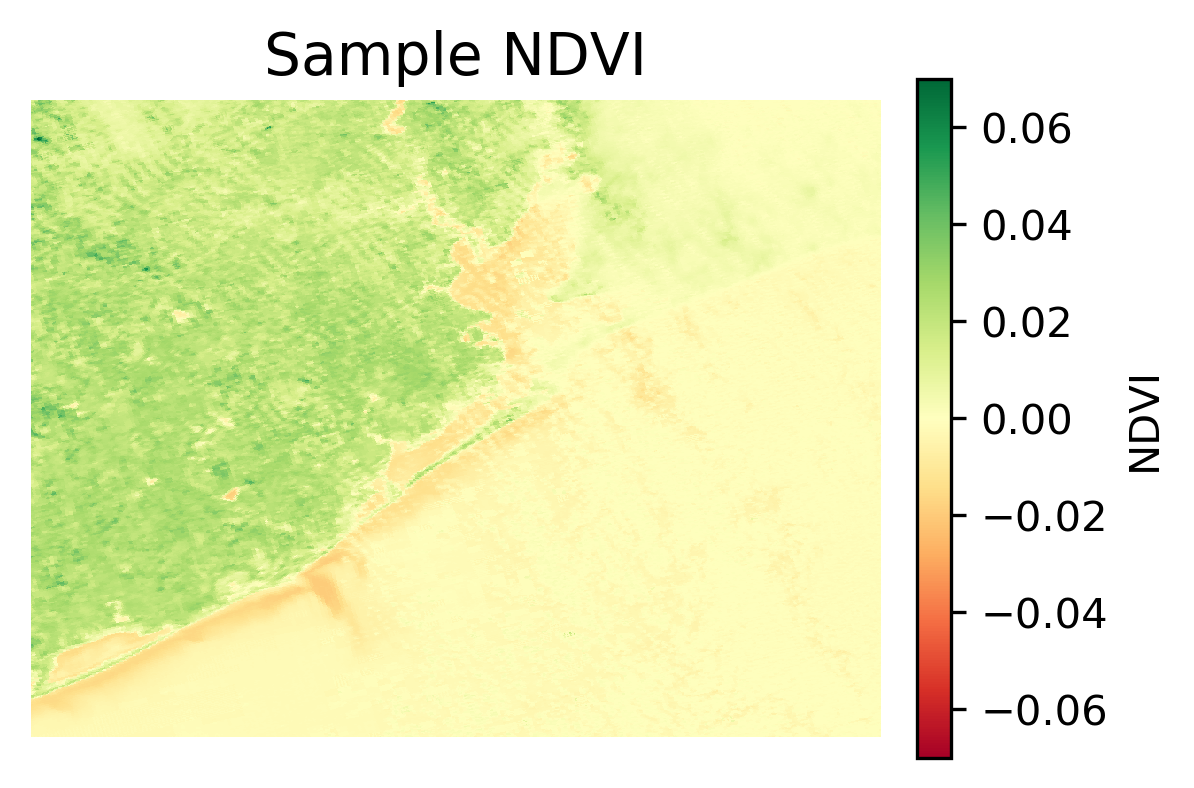

In [18]:
#red band path
#red_path = '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019364000000_aid0001.tif'
red_path = '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019019000000_aid0001.tif'
 
#nir path
#nir_path = '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b02_1_doy2019364000000_aid0001.tif'
nir_path = '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b02_1_doy2019019000000_aid0001.tif'

# #green path
# green_path = '/shared_space/Galveston_Bay/MODIS_500//MYD09GQ.061_sur_refl_b02_1_doy2019019000000_aid0001.tif'

# #blue path
# blue_path = 
 
#normalize RGB values to 0-1 using min-max normalization
def normalize(array):
    array_min, array_max = array.min(), array.max() #find min and max of array
    return (array - array_min) / (array_max - array_min) #min-max norm calc

# read arrays
with rasterio.open(red_path) as red_src, rasterio.open(nir_path) as nir_src:
    red = red_src.read(1).astype(float) #convert to floats
    nir = nir_src.read(1).astype(float)
    #extratc width and height for lat, lon
    width = red_src.width
    height = red_src.height
    transform = red_src.transform  # affine transformation matrix

# normalize to 0–1
red_norm = normalize(red)
nir_norm = normalize(nir)

# compute NDVI
ndvi = (nir_norm - red_norm) / (nir_norm + red_norm)


# plot NDVI
plt.figure(figsize=(4,3), dpi = 300)
ndvi_plot = plt.imshow(ndvi, cmap='RdYlGn', vmin = -0.07, vmax = 0.07) #ndvi varies btw -1 and 1
#customize colorbar
plt.colorbar(ndvi_plot, fraction=0.046, pad=0.04, label="NDVI")
#plot properties
plt.title("Sample NDVI", fontsize =14)
plt.axis("off")
plt.show()

In [19]:
#set up meshgrid
cols, rows = np.meshgrid(np.arange(width), np.arange(height))

#transform to lon, lat
xs, ys = rasterio.transform.xy(transform, rows, cols)
lons = np.array(xs)
lats = np.array(ys)


In [20]:
# example: extract lat, lon for specific pixel
top_left_lon = lons[0, 0]
top_left_lat = lats[0, 0]

print(f"Top-left longitude: {top_left_lon}")
print(f"Top-left latitude: {top_left_lat}")

Top-left longitude: -96.00104165806638
Top-left latitude: 30.001041663979017


In [21]:
#test parse date function
date_string = parse_date(red_path)
print(date_string)

2019019


In [22]:
#test strign to datetime function
date = string_to_timestamp(date_string)
print(date)

2019-01-19 00:00:00


In [23]:
#test datetime matching
from datetime import datetime

target_timestamp = date

closest_timestamp = min(fp['datetime_utc'], key=lambda ts: abs(target_timestamp - ts))
print(closest_timestamp)

2019-01-24 06:00:00


In [24]:
#convert lat, lon to np arrays
ys = np.array(ys)
xs = np.array(xs)

In [25]:
#test lat, lon matching
# target point (in our grid)
target_lat = 29
target_lon = -95.2

# calculate sq euclidean differences 
lat_diff_sq = (ys - target_lat)**2
lon_diff_sq = (xs - target_lon)**2

distance_sq = lat_diff_sq + lon_diff_sq

# find the index of the minimum distance
min_idx = np.unravel_index(np.argmin(distance_sq), distance_sq.shape)

# get the nearest grid point coordinates
nearest_lat = ys[min_idx]
nearest_lon = xs[min_idx]
#print result
print(f"Nearest grid point: Lat={nearest_lat}, Lon={nearest_lon}")

Nearest grid point: Lat=29.0010416640686, Lon=-95.20104165813805


### match MODIS and targets

In [50]:
# configurations
SCALE = 0.0001                # MODIS SUR_REFL scale factor
TIME_TOL = pd.Timedelta("96h")# max allowed difference between obs and MODIS scene
USE_FALLBACK = True          # set True to enable KDTree fallback (more expensive)
FALLBACK_MAX_KM = 100.0        # max distance to accept fallback pixel

In [51]:
# extract YYYYDDD from filename
def extract_year_doy(s):
    if s is None:
        return None
    s = str(s)
    m = re.search(r'doy(\d{7})', s, flags=re.IGNORECASE)
    if m:
        return m.group(1)
    m2 = re.search(r'(\d{4})(\d{3})', s)
    if m2:
        return m2.group(1) + m2.group(2)
    return None

In [52]:
# #convert string to timestamp
# def year_doy_to_ts(yyyydoy):
#     year = int(yyyydoy[:4]); doy = int(yyyydoy[4:7])
#     return pd.to_datetime(f"{year}-{doy}", format="%Y-%j")

def year_doy_to_ts(yyyydoy):
    # yyyydoy can be either string '2019001' or a tuple (year,doy)
    if isinstance(yyyydoy, str) and len(yyyydoy) >= 7:
        year = int(yyyydoy[:4])
        doy  = int(yyyydoy[4:7])
        return pd.to_datetime(datetime(year, 1, 1) + timedelta(days=doy-1))
    # if it's already a Timestamp or date
    return pd.to_datetime(yyyydoy)

In [53]:
from datetime import timedelta

raw_keys = list(groups.keys())   # your original keys (strings like '2019001' or date objects)
scene_tuples = []   # list of (orig_key, parsed_ts, orig_pos)

for pos, k in enumerate(raw_keys):
    try:
        ek = extract_year_doy(k)   # your function that returns yyyydoy string or None
    except Exception:
        ek = None

    if ek is None:
        # keep track of bad keys if you want
        bad_keys.append(k)
        continue

    ts = year_doy_to_ts(ek)   # convert to pandas Timestamp
    if pd.isna(ts):
        bad_keys.append(k)
        continue

    scene_tuples.append((k, ts, pos))

if len(scene_tuples) == 0:
    raise RuntimeError("No valid scene keys parsed from groups.")

# sort by timestamp (chronological order) -> this gives a monotonic index for get_indexer
scene_tuples_sorted = sorted(scene_tuples, key=lambda t: t[1])

# Build sorted scene_index (monotonic increasing)
sorted_timestamps = [t[1] for t in scene_tuples_sorted]
scene_index = pd.DatetimeIndex(sorted_timestamps)

# Also build mapping: sorted-position -> original position and -> original key
sortedpos_to_origpos = [t[2] for t in scene_tuples_sorted]   # list indexed by sorted position
sortedpos_to_origkey = [t[0] for t in scene_tuples_sorted]    # same length, original keys

In [32]:
# when added 2018, this wasn't ordering things correctly for some reason so used above code to parse dates from modis files
# build valid scene keys and index (scene = matching red, nir, qc file group)
# raw_keys = list(groups.keys())
# scene_keys = []
# bad_keys = []
# for k in raw_keys:
#     ek = extract_year_doy(k)
#     if ek is not None:
#         scene_keys.append(ek)
#     else:
#         bad_keys.append(k)
# if len(scene_keys) == 0:
#     raise RuntimeError("No valid scene keys parsed from groups.")
# scene_times = [year_doy_to_ts(k) for k in scene_keys]
# scene_index = pd.DatetimeIndex(scene_times)

# #len(scene_index)

In [61]:
any_2018 = any(d.year == 2018 for d in scene_index)
print(any_2018)

True


In [63]:
# match nearest datetime

# extract matching datetime index
idx_for_obs = scene_index.get_indexer(fp['datetime_utc'], method='nearest', tolerance=TIME_TOL)
fp['modis_scene_idx'] = idx_for_obs 

# store time diff in minutes (may be used as a feature)
matched_times = pd.Series([scene_index[i] if i >= 0 else pd.NaT for i in idx_for_obs], index=fp.index)
fp['modis_time_diff_min'] = (fp['datetime_utc'] - matched_times).abs().dt.total_seconds() / 60.0


# init output cols
fp['modis_red'] = np.nan
fp['modis_nir'] = np.nan
fp['modis_ratio'] = np.nan
fp['modis_nd'] = np.nan
fp['modis_green'] = np.nan
fp['modis_blue'] = np.nan
fp['modis_chlor'] = np.nan

# match by lat lon 
#loop through datetime and matching obs index
for scene_idx, scene_key in enumerate(scene_keys):
    # find obs indices assigned to this scene
    obs_idx = np.where(fp['modis_scene_idx'].values == scene_idx)[0]

    # find files for this group (allow fallback: try searching flist for a matching key)
    flist = groups.get(scene_key, None)

    #extract files_paths for group
    red_fp = next((f for f in flist if '_sur_refl_b01' in os.path.basename(f).lower()), None)
    nir_fp = next((f for f in flist if '_sur_refl_b02' in os.path.basename(f).lower()), None)
    blue_fp = next((f for f in flist if '_sur_refl_b03' in os.path.basename(f).lower()), None)
    green_fp = next((f for f in flist if '_sur_refl_b04' in os.path.basename(f).lower()), None)
    qc_fp  = next((f for f in flist if '_qc' in os.path.basename(f).lower()), None)
    if not (red_fp and nir_fp and blue_fp and green_fp and qc_fp):
        # skip incomplete scenes
        continue

    # build coordinate pairs
    #coords = [(fp.loc[i,'lon'], fp.loc[i,'lat']) for i in obs_idx]
    coords = [(fp.iloc[i]['lon'], fp.iloc[i]['lat']) for i in obs_idx]


    # open rasters and batch-sample at coordinates
    with rasterio.open(red_fp) as rsrc, rasterio.open(nir_fp) as nsrc, rasterio.open(qc_fp) as qsrc, rasterio.open(blue_fp) as bsrc, rasterio.open(green_fp) as gsrc:
        raw_red = np.array([v[0] for v in rsrc.sample(coords)], dtype=np.float32)
        raw_nir = np.array([v[0] for v in nsrc.sample(coords)], dtype=np.float32)
        raw_blue = np.array([v[0] for v in bsrc.sample(coords)], dtype=np.float32)
        raw_green = np.array([v[0] for v in gsrc.sample(coords)], dtype=np.float32)
        raw_qc  = np.array([v[0] for v in qsrc.sample(coords)], dtype=np.uint16)

        # decode QC on sampled QC values
        #modland_qa = raw_qc & 0b11 #??
        #produced   = (raw_qc & (1 << 2)) == 0 
        #aerosol_ok = (raw_qc & 0b11110000) == 0
        #good_sample = np.isin(modland_qa, [0,1]) & produced & aerosol_ok

        modland = raw_qc & 0b11
        data_produced = ((raw_qc >> 2) & 1) == 0
        aerosol_quality = (raw_qc >> 4) & 0b1111

        good_sample = (modland <= 2) & data_produced & (aerosol_quality <= 3)

        # mask sampled values and scale
        red_sample = raw_red.astype(np.float32)
        nir_sample = raw_nir.astype(np.float32)
        blue_sample = raw_blue.astype(np.float32)
        green_sample = raw_green.astype(np.float32)
        red_sample[~good_sample] = np.nan
        nir_sample[~good_sample] = np.nan
        blue_sample[~good_sample] = np.nan
        green_sample[~good_sample] = np.nan
        red_sample *= SCALE
        nir_sample *= SCALE
        blue_sample *= SCALE
        green_sample *= SCALE
        

        # compute red/nir and ndvi (nd_sample) and chlorophyll-a
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio_sample = red_sample / nir_sample
            nd_sample = (red_sample - nir_sample) / (red_sample + nir_sample)
            chl_sample = blue_sample / green_sample
            
        # assign sampled results back to fp (vectorized)
        out_vals = np.column_stack((red_sample, nir_sample, ratio_sample, nd_sample, blue_sample, green_sample, chl_sample))
        cols = ['modis_red','modis_nir','modis_ratio','modis_nd', 'modis_blue','modis_green','modis_chlor']        
        
        fp.loc[fp.index[obs_idx], cols] = out_vals

In [64]:
print(fp.head())

      DateTime      lat      lon        DO            datetime_local  \
935 2018-01-23  29.5566 -94.9045  9.149207 2018-01-23 00:00:00-06:00   
936 2018-01-23  29.5566 -94.9045  9.086007 2018-01-23 00:00:00-06:00   
937 2018-01-23  29.5566 -94.9045  9.109207 2018-01-23 00:00:00-06:00   
938 2018-01-23  29.5566 -94.9045  9.156907 2018-01-23 00:00:00-06:00   
939 2018-01-23  29.5566 -94.9045  9.093707 2018-01-23 00:00:00-06:00   

           datetime_utc  modis_scene_idx  modis_time_diff_min  modis_red  \
935 2018-01-23 06:00:00               22                360.0     0.4121   
936 2018-01-23 06:00:00               22                360.0     0.4121   
937 2018-01-23 06:00:00               22                360.0     0.4121   
938 2018-01-23 06:00:00               22                360.0     0.4121   
939 2018-01-23 06:00:00               22                360.0     0.4121   

     modis_nir  modis_ratio  modis_nd  modis_green  modis_blue  modis_chlor  
935     0.4093     1.006841  0.0

In [65]:
print("obs min/max:", fp['datetime_utc'].min(), fp['datetime_utc'].max())
print("sample obs (2019-2020):")
print(fp[(fp['datetime_utc'] >= '2018-01-01') & (fp['datetime_utc'] < '2021-01-01')].head(15))
print(len(fp[(fp['datetime_utc'] >= '2018-01-01') & (fp['datetime_utc'] < '2021-01-01')]))


obs min/max: 2018-01-23 06:00:00 2020-12-17 06:00:00
sample obs (2019-2020):
      DateTime      lat      lon        DO            datetime_local  \
935 2018-01-23  29.5566 -94.9045  9.149207 2018-01-23 00:00:00-06:00   
936 2018-01-23  29.5566 -94.9045  9.086007 2018-01-23 00:00:00-06:00   
937 2018-01-23  29.5566 -94.9045  9.109207 2018-01-23 00:00:00-06:00   
938 2018-01-23  29.5566 -94.9045  9.156907 2018-01-23 00:00:00-06:00   
939 2018-01-23  29.5566 -94.9045  9.093707 2018-01-23 00:00:00-06:00   
940 2018-01-23  29.5566 -94.9045  9.116907 2018-01-23 00:00:00-06:00   
941 2018-01-23  29.5566 -94.9045  9.137607 2018-01-23 00:00:00-06:00   
942 2018-01-23  29.5566 -94.9045  9.068607 2018-01-23 00:00:00-06:00   
943 2018-01-23  29.5566 -94.9045  9.091807 2018-01-23 00:00:00-06:00   
944 2018-01-23  29.6394 -95.0029  9.188100 2018-01-23 00:00:00-06:00   
945 2018-01-23  29.6394 -95.0029  9.143333 2018-01-23 00:00:00-06:00   
946 2018-01-23  29.6394 -95.0029  9.078350 2018-01-23 00:00

In [66]:
#re-define y
y = fp['DO'].values

In [67]:
# define variables 
era_vars = list(ds.data_vars)   
obs_vars = ['modis_time_diff_min', 'modis_red', 'modis_nir', 'modis_ratio', 'modis_nd','modis_blue','modis_green','modis_chlor']

n_obs = len(fp)         
n_pred = len(era_vars) + len(obs_vars) + 5 #added 2 for lat, lon, and time(year,month,doy)

# match era by datetime, lat, lon
def extract_at_site_and_time(da, sitetime, site_lat, site_lon):
    sel = da.sel({'latitude': site_lat, 'longitude': site_lon, 'valid_time': sitetime},
                 method='nearest')
    val = np.asarray(sel.values).squeeze()

    return float(val)

In [68]:
# tolerance settings (adjust to taste)
TIME_TOL_MIN = 12 * 60   # minutes
KM_TOL = 5.0             # kilometers

# build boolean mask: True if we have a valid MODIS match within tolerances
# modis_red must be finite (not NaN) to indicate a sampled pixel
modis_ok = np.isfinite(fp['modis_red'].values)

# modis_time_diff_min must be finite and <= TIME_TOL_MIN
time_ok = np.isfinite(fp['modis_time_diff_min'].values) & (fp['modis_time_diff_min'].values <= TIME_TOL_MIN)

# pixel distance: if modis_pixel_dist_km is NaN that usually means direct sample success
# treat NaN as acceptable; otherwise require <= KM_TOL
#pixdist = fp['modis_pixel_dist_km'].values
#pix_ok = np.isnan(pixdist) | (pixdist <= KM_TOL)

# final mask: only rows with valid MODIS and within both tolerances
use_mask = modis_ok & time_ok 

print("Total obs:", len(fp), "Selected for ERA5 matching:", use_mask.sum())


Total obs: 1679 Selected for ERA5 matching: 1614


In [69]:
# indices to process
idxs = np.where(use_mask)[0]
n_selected = idxs.size

# build X_selected with only selected rows
X_selected = np.full((n_selected, n_pred), np.nan, dtype=float)
print(np.shape(X_selected))

for ii, i in enumerate(idxs):
    s_lat = lat_obs.iloc[i] if hasattr(lat_obs, 'iloc') else lat_obs[i]
    s_lon = lon_obs.iloc[i] if hasattr(lon_obs, 'iloc') else lon_obs[i]
    s_time = pd.to_datetime(fp['datetime_utc'].iloc[i])

    # ERA5 vars
    for j, varname in enumerate(era_vars):
        try:
            X_selected[ii, j] = extract_at_site_and_time(ds[varname], s_time, s_lat, s_lon)
        except Exception:
            X_selected[ii, j] = np.nan

    # add MODIS obs vars (these are already good by mask)
    base = len(era_vars)
    for k, col in enumerate(obs_vars):
        val = fp[col].iloc[i]
        X_selected[ii, base + k] = float(val) if np.isfinite(val) else np.nan
        
    # finally add lat, lon and time
    X_selected[ii, base + len(obs_vars)]     = float(s_lat)
    X_selected[ii, base + len(obs_vars) + 1] = float(s_lon)
    #apparently it won't like datetime format, so broke it up into three columns
    X_selected[ii, base + len(obs_vars) + 2] = int(s_time.year)
    X_selected[ii, base + len(obs_vars) + 3] = int(s_time.month)
    X_selected[ii, base + len(obs_vars) + 4] = int(s_time.dayofyear)


# X_selected and corresponding targets:
y_selected = y.iloc[idxs] if hasattr(y, 'iloc') else y[idxs]

X_selected[367]

(1614, 18)


array([ 2.08628845e+00,  3.67804871e+00,  3.59999877e-12,  2.99135303e+02,
        4.22855079e+00,  3.00000000e+02,  2.24699989e-01,  1.50799990e-01,
        1.49005306e+00,  1.96804285e-01,  1.73400000e-01,  2.21999988e-01,
        7.81081140e-01,  2.94629000e+01, -9.48584000e+01,  2.01800000e+03,
        5.00000000e+00,  1.50000000e+02])

In [70]:
print(X_selected.shape)
print(y_selected.shape)
print(X_selected)

(1614, 18)
(1614,)
[[ 1.89269836e+00 -1.54909241e+00  3.59999877e-12 ...  2.01800000e+03
   1.00000000e+00  2.30000000e+01]
 [ 1.89269836e+00 -1.54909241e+00  3.59999877e-12 ...  2.01800000e+03
   1.00000000e+00  2.30000000e+01]
 [ 1.89269836e+00 -1.54909241e+00  3.59999877e-12 ...  2.01800000e+03
   1.00000000e+00  2.30000000e+01]
 ...
 [-7.22686768e-01 -2.58949280e+00  3.59999877e-12 ...  2.02000000e+03
   1.20000000e+01  3.52000000e+02]
 [-7.22686768e-01 -2.58949280e+00  3.59999877e-12 ...  2.02000000e+03
   1.20000000e+01  3.52000000e+02]
 [-7.22686768e-01 -2.58949280e+00  3.59999877e-12 ...  2.02000000e+03
   1.20000000e+01  3.52000000e+02]]


In [71]:
header_line  = [era_vars+obs_vars]
print(header_line)
header_line = 'u10, v10, wind_speed, ssr, t2m, modis_time_diff_min, red, nir, red_over_nir, ndvi, modis_blue, modis_green, modis_chlor, lat, lon, year, month, dayofyear'

[['u10', 'v10', 'ssr', 't2m', 'wind_speed', 'modis_time_diff_min', 'modis_red', 'modis_nir', 'modis_ratio', 'modis_nd', 'modis_blue', 'modis_green', 'modis_chlor']]


In [72]:
np.savetxt('/shared_space/Galveston_Bay/samples.csv',
           X_selected,
           delimiter=',',
           fmt='%.2f',
           header=header_line,
           comments='')

np.savetxt('/shared_space/Galveston_Bay/targets.csv',
           y_selected,
           delimiter=',',
           fmt='%.2f',
           header='ground_obs',
           comments='')


In [73]:
#KEEP only wind_speed and sst (has lots of NaNs so be careful)
#X = np.delete(X, [0, 1], axis=1)
#print(X)

In [74]:
X = X_selected
y = y_selected

In [75]:
#reading in data for below plots that way don't have to run everything above again
X = pd.read_csv('/shared_space/Galveston_Bay/samples.csv')
y = pd.read_csv('/shared_space/Galveston_Bay/targets.csv')

In [76]:
X.head()


,u10,v10,wind_speed,ssr,t2m,modis_time_diff_min,red,nir,red_over_nir,ndvi,modis_blue,modis_green,modis_chlor,lat,lon,year,month,dayofyear
0,1.89,-1.55,0.0,281.89,2.45,360.0,0.41,0.41,1.01,0.0,0.39,0.41,0.95,29.56,-94.9,2018.0,1.0,23.0
1,1.89,-1.55,0.0,281.89,2.45,360.0,0.41,0.41,1.01,0.0,0.39,0.41,0.95,29.56,-94.9,2018.0,1.0,23.0
2,1.89,-1.55,0.0,281.89,2.45,360.0,0.41,0.41,1.01,0.0,0.39,0.41,0.95,29.56,-94.9,2018.0,1.0,23.0
3,1.89,-1.55,0.0,281.89,2.45,360.0,0.41,0.41,1.01,0.0,0.39,0.41,0.95,29.56,-94.9,2018.0,1.0,23.0
4,1.89,-1.55,0.0,281.89,2.45,360.0,0.41,0.41,1.01,0.0,0.39,0.41,0.95,29.56,-94.9,2018.0,1.0,23.0


In [121]:
## outlier detection

plt.hist(X[:,2], bins=30, edgecolor='black')  # 'bins' controls the number of bars, 'edgecolor' adds borders

# Add labels and title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Wind Speed Data")

# Display the plot
plt.show()


plt.hist(X[:,2], bins=30, edgecolor='black')  # 'bins' controls the number of bars, 'edgecolor' adds borders

# Add labels and title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Sea Surface Temperature Data")

# Display the plot
plt.show()

plt.hist(X[:,4], bins=30, edgecolor='black')  # 'bins' controls the number of bars, 'edgecolor' adds borders

# Add labels and title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("2m Temperature Data")

# Display the plot
plt.show()

plt.hist(X[:,6], bins=30, edgecolor='black')  # 'bins' controls the number of bars, 'edgecolor' adds borders

# Add labels and title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Red Data")

# Display the plot
plt.show()

plt.hist(X[:,7], bins=30, edgecolor='black')  # 'bins' controls the number of bars, 'edgecolor' adds borders

# Add labels and title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("NIR Data")

# Display the plot
plt.show()

plt.hist(X[:,9], bins=30, edgecolor='black')  # 'bins' controls the number of bars, 'edgecolor' adds borders

# Add labels and title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("NDVI Data")

# Display the plot
plt.show()

TypeError: unhashable type: 'slice'

In [122]:
os.getcwd()
os.chdir('/home/jovyan/work/GalvestonBay')
os.getcwd()

FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/work/GalvestonBay'

In [127]:
X.columns

Index(['u10', ' v10', ' wind_speed', ' ssr', ' t2m', ' modis_time_diff_min',
       ' red', ' nir', ' red_over_nir', ' ndvi', ' modis_blue', ' modis_green',
       ' modis_chlor', ' lat', ' lon', ' year', ' month', ' dayofyear'],
      dtype='object')

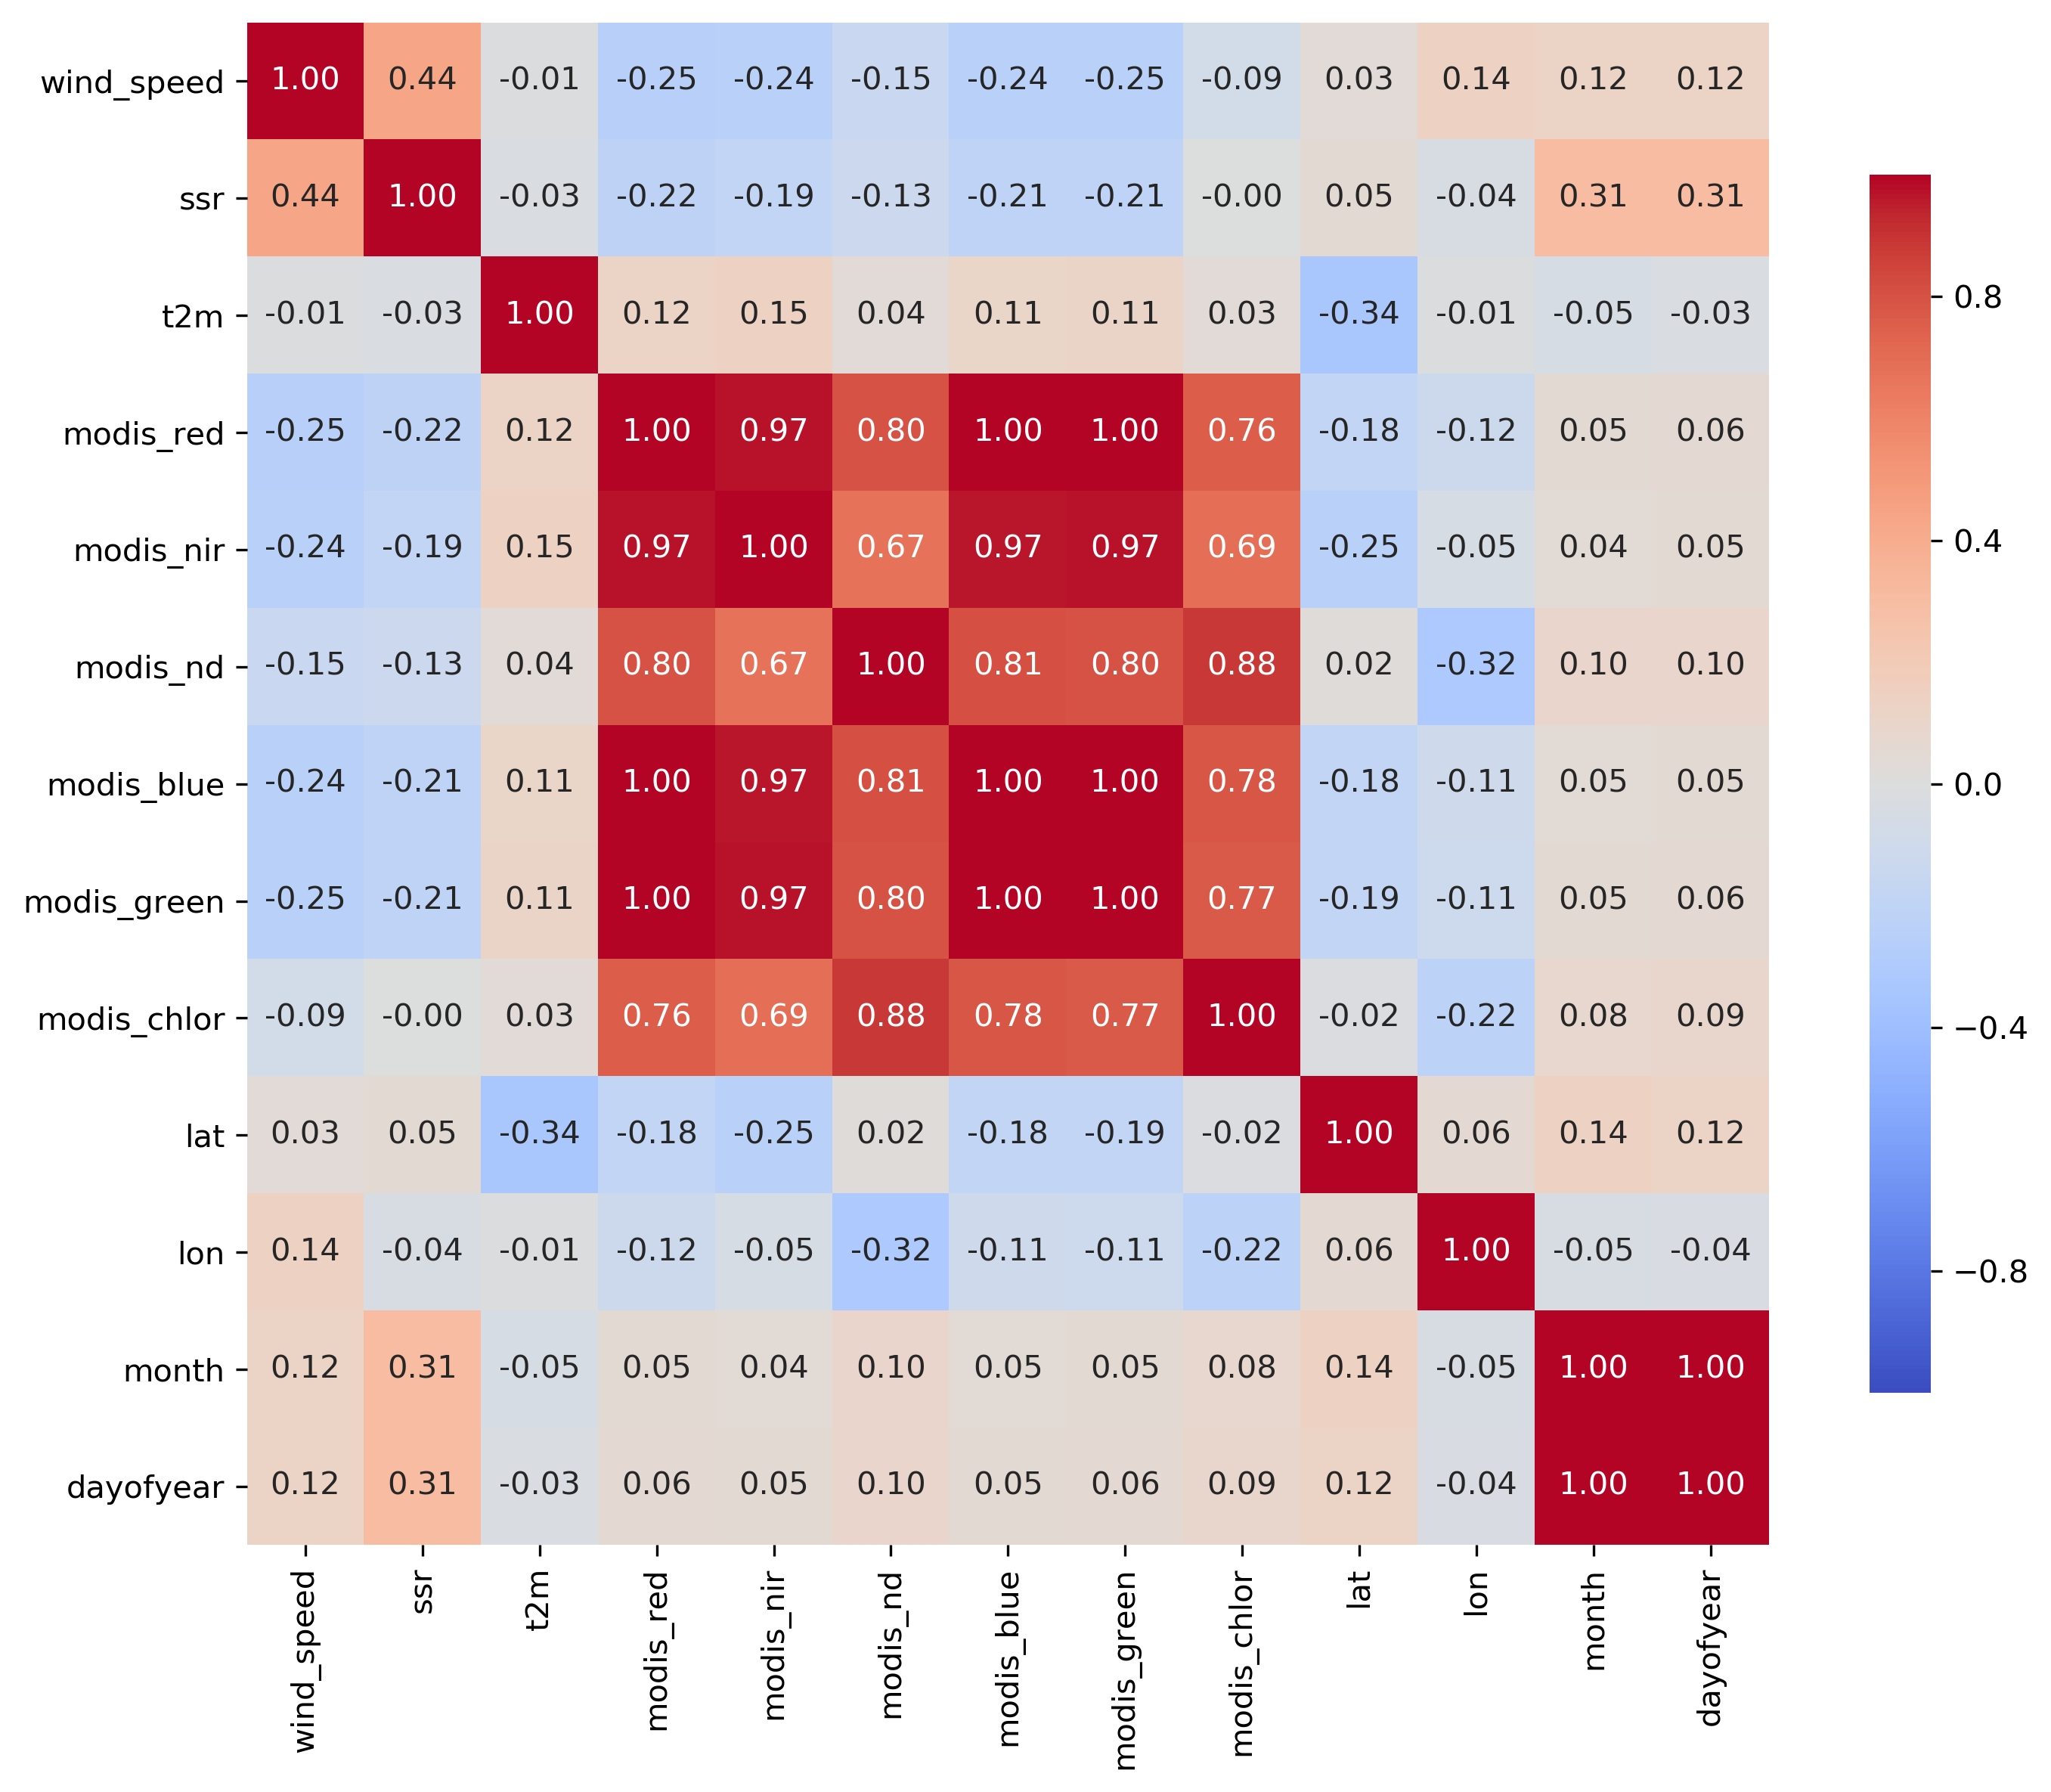

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


#feature_names = era_vars+obs_vars
feature_names = ['wind_speed','ssr', 't2m', 'modis_red', 'modis_nir', 'modis_nd', 'modis_blue','modis_green','modis_chlor','lat', 'lon', 'month', 'dayofyear'] 
X = X.drop(columns=['u10', ' v10', ' modis_time_diff_min',' red_over_nir',' year'])#np.delete(X, [0, 1,5,8,12], axis=1) 
#corr = np.corrcoef(X[~np.isnan(X).any(axis=1)], rowvar=False)
corr = np.corrcoef(X, rowvar=False)
n = corr.shape[0]
fig, ax = plt.subplots(figsize=(10,8), dpi=300)   # square figure helps
sns.heatmap(
    corr,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    annot=True,
    xticklabels=feature_names,
    yticklabels=feature_names,
    vmin=-1, vmax=1,
    ax=ax,
    cbar_kws={"shrink": 0.8}    # shrink colorbar so it doesn't force axis resizing
)

# force axis to exactly span the full grid used by pcolormesh
ax.set_xlim(0, n)
ax.set_ylim(n, 0)   # note: pcolormesh flips y axis, so set top->bottom
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
#plt.savefig("feature_corr_new.png", dpi=300)   # try WITHOUT bbox_inches='tight' first
plt.show()


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:27: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations


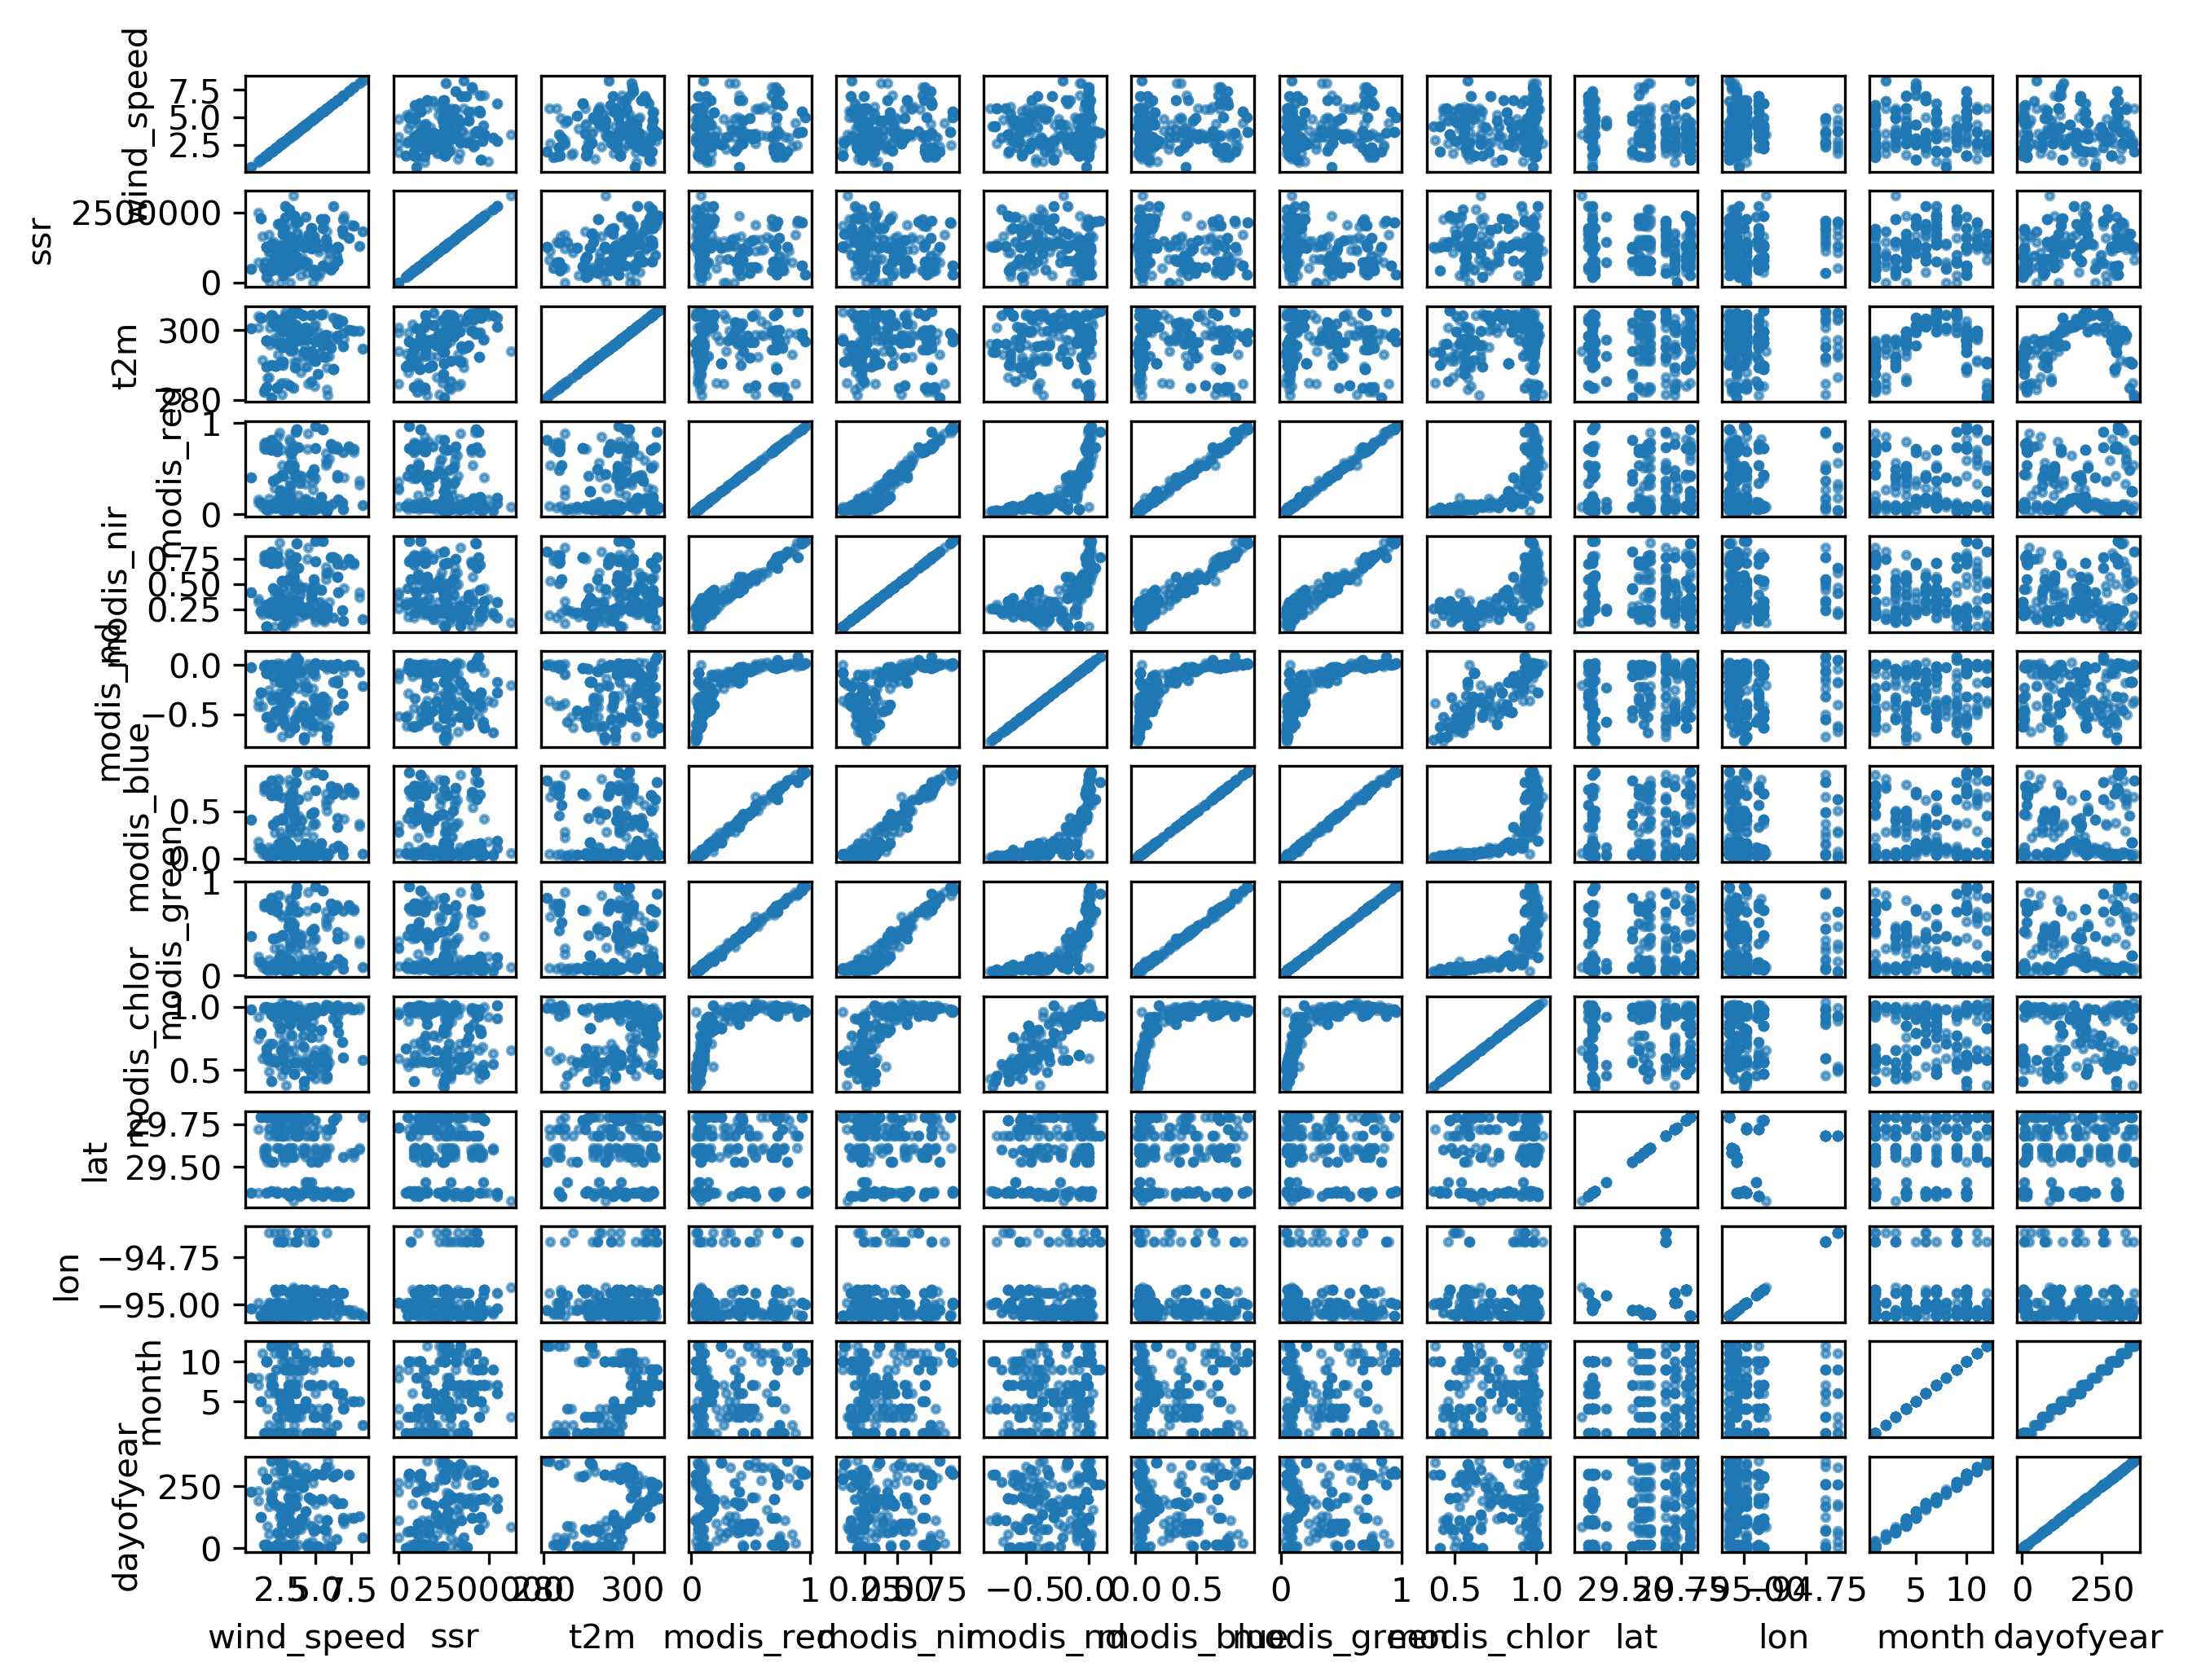

In [131]:
import pandas as pd
#import matplotlib.pyplot as plt
import itertools

#df = pd.DataFrame(X, columns=feature_names)
df = X
#print(X.columns)
n = len(X.columns)#len(feature_names)
fig, axs = plt.subplots(n, n, figsize=(10,8), dpi=300)

for i, j in itertools.product(range(n), range(n)):
    ax = axs[i, j]

    # scatter
    ax.scatter(df.iloc[:, j], df.iloc[:, i], s=5, alpha=0.6)

    if i == n-1:
        ax.set_xlabel(feature_names[j])
    else:
        ax.set_xticks([])

    if j == 0:
        ax.set_ylabel(feature_names[i])
    else:
        ax.set_yticks([])

plt.tight_layout()
#plt.savefig("feature_scatter_matrix.png", dpi=300)
plt.show()


In [41]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df = pd.DataFrame(X_scaled, columns=feature_names)


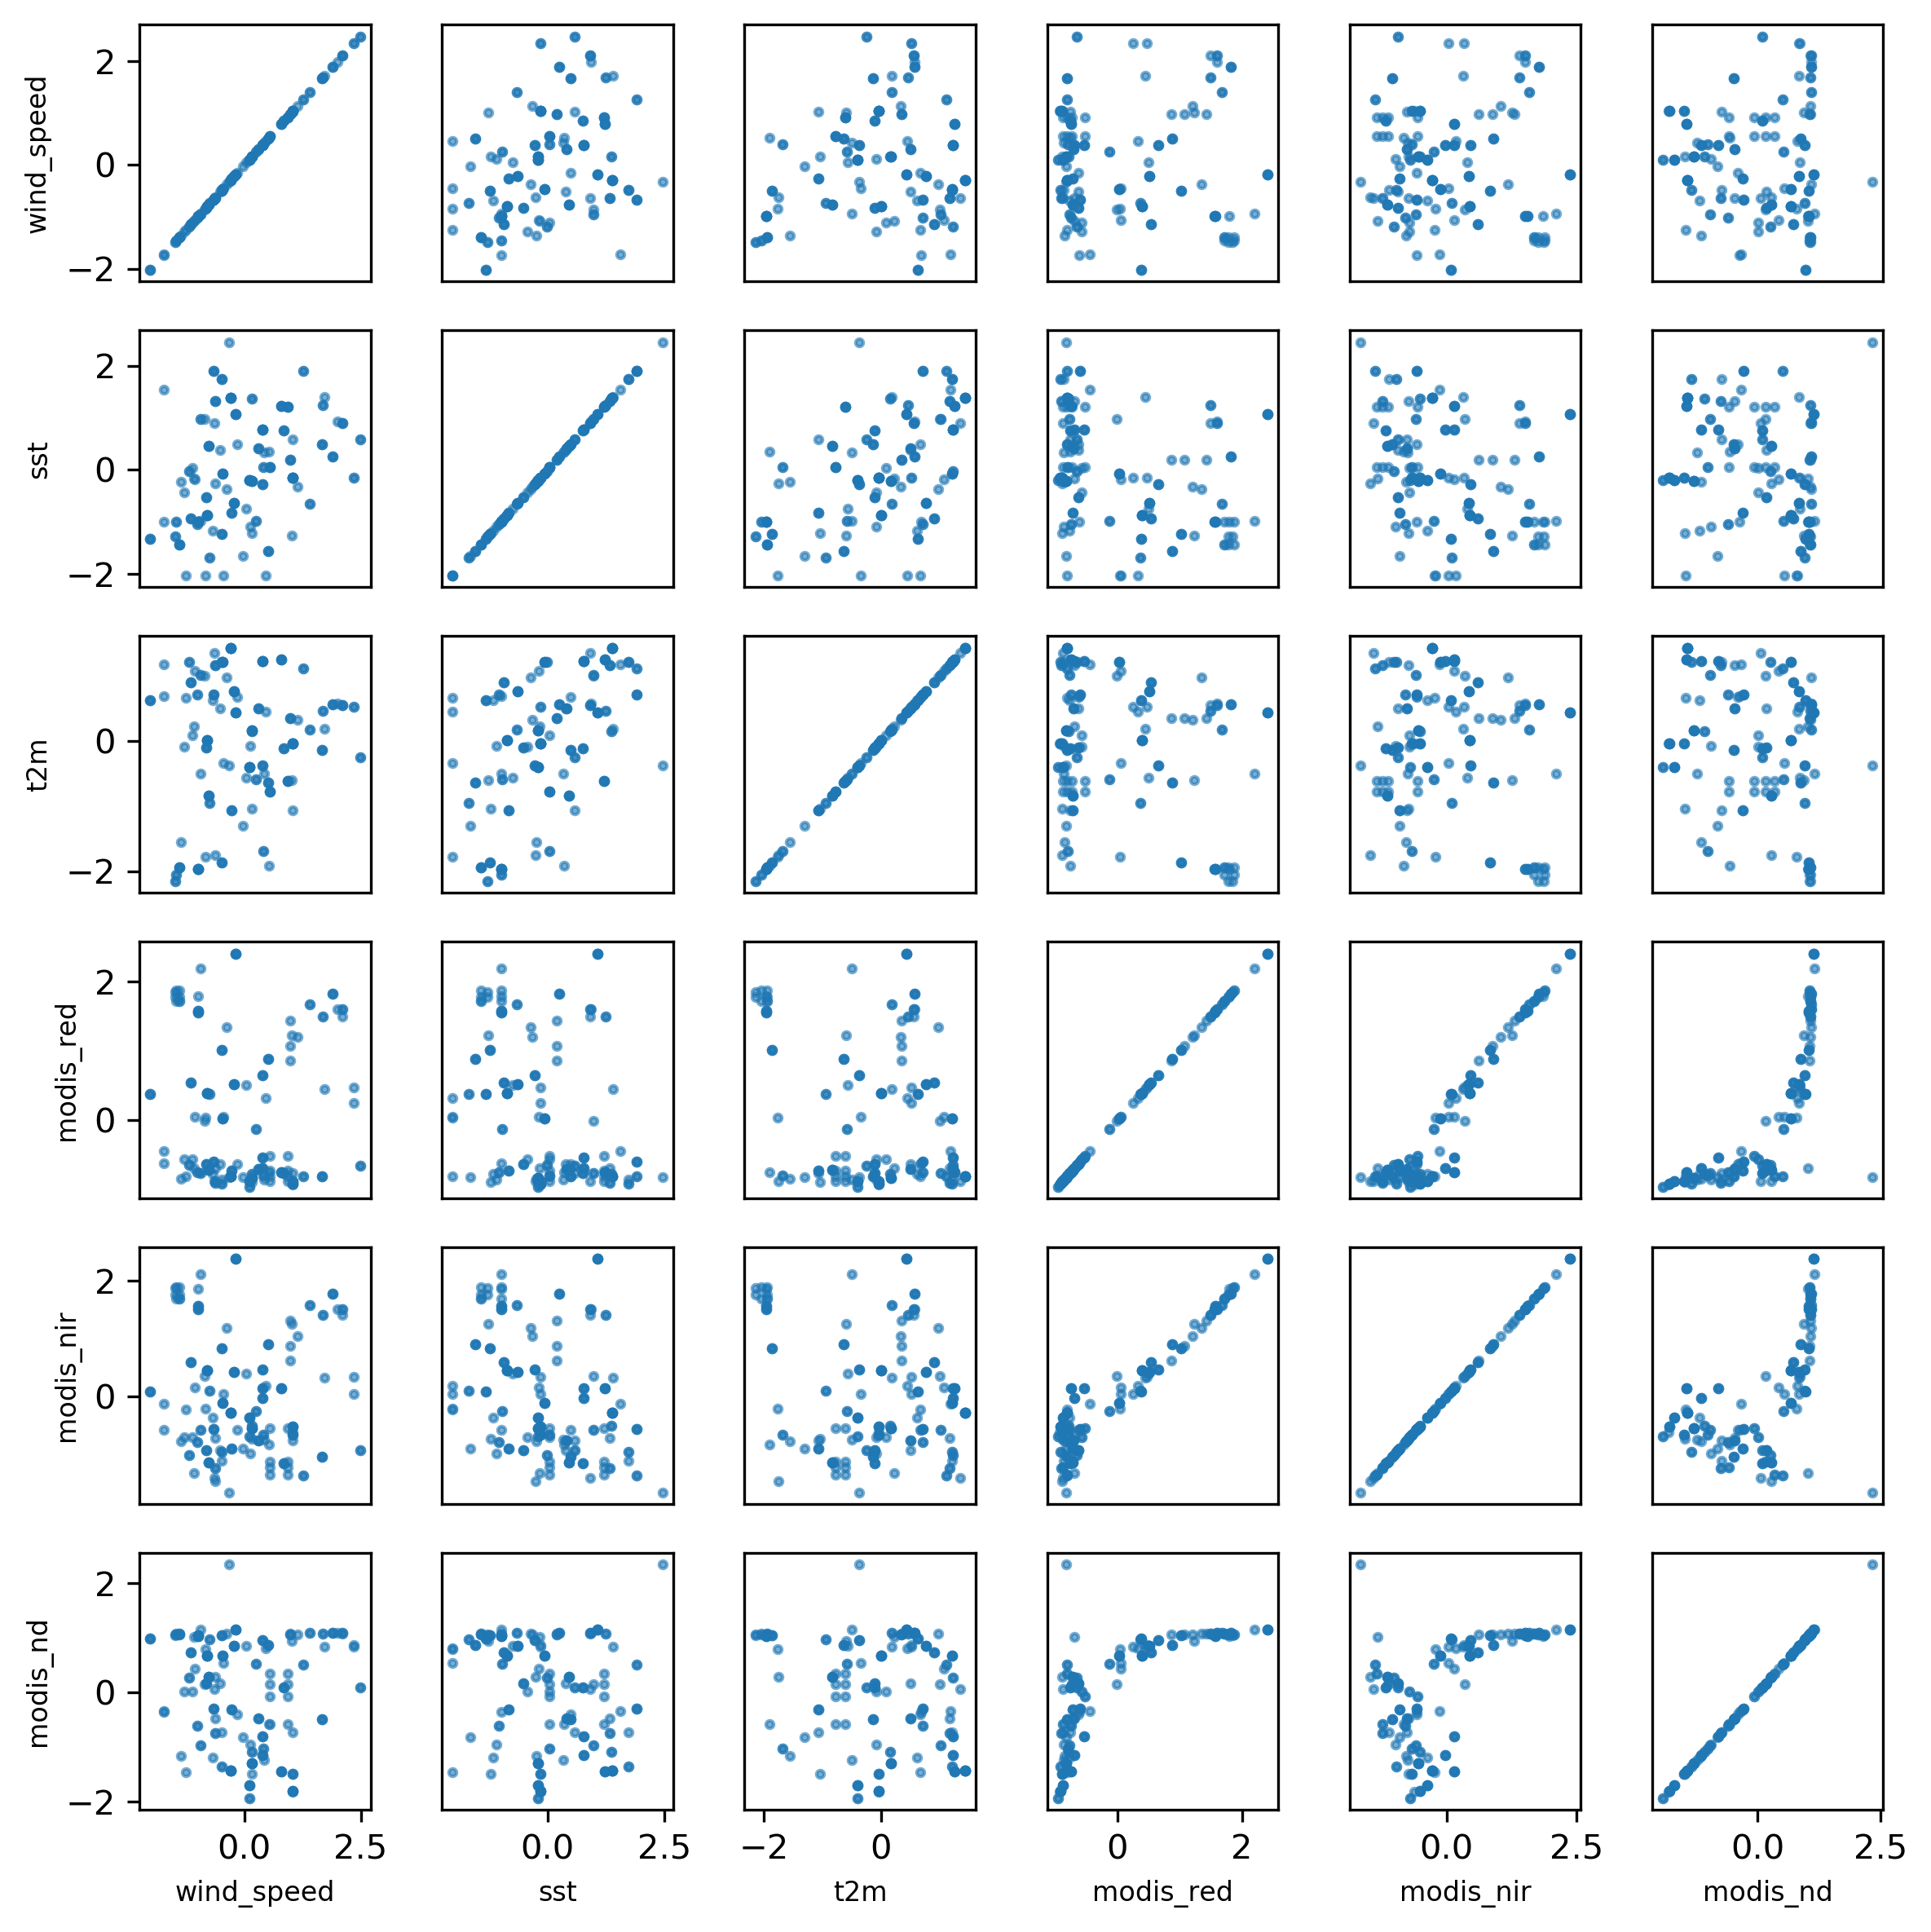

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from sklearn.preprocessing import StandardScaler

# --- SCALE FEATURES ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df = pd.DataFrame(X_scaled, columns=feature_names)

# --- SCATTER MATRIX ---
n = len(feature_names)
fig, axs = plt.subplots(n, n, figsize=(8,8), dpi=300)

for i, j in itertools.product(range(n), range(n)):
    ax = axs[i, j]


    # Scatter
    ax.scatter(df.iloc[:, j], df.iloc[:, i], s=5, alpha=0.6)

    # Axis labeling
    if i == n-1:
        ax.set_xlabel(feature_names[j], fontsize=8)
    else:
        ax.set_xticks([])

    if j == 0:
        ax.set_ylabel(feature_names[i], fontsize=8)
    else:
        ax.set_yticks([])

plt.tight_layout()
plt.savefig("feature_scatter_matrix_scaled.png", dpi=300)
plt.show()


In [43]:
print(X.shape)

(184, 6)
